# VI vs MCMC
## 1.1 Basic VI — Mean Field Variational Inference

### Генерация данных

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, init_to_median

from sklearn.cluster import KMeans

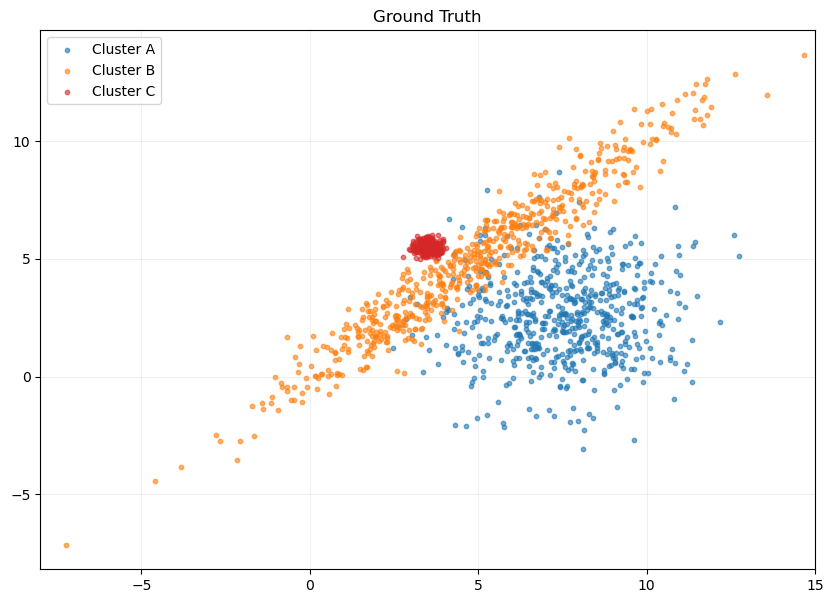

In [2]:
def generate_complex_gmm_data_with_labels(n_samples=1500):
    torch.manual_seed(42)
    
    # 1. Кластер A: Широкий (n=600)
    loc_a = torch.tensor([7.5, 2.5])
    data_a = torch.randn(600, 2) * 1.8 + loc_a
    labels_a = torch.zeros(600)
    
    # 2. Кластер B: Вытянутый по диагонали (n=600)
    loc_b = torch.tensor([5.0, 5.0])
    scale_b = torch.tensor([4.5, 0.6]) 
    theta = torch.tensor([torch.pi / 4])  # 45 градусов
    rot = torch.tensor([[theta.cos(), -theta.sin()], [theta.sin(), theta.cos()]])
    data_b = (torch.randn(600, 2) * scale_b) @ rot.T + loc_b
    labels_b = torch.ones(600)
    
    # 3. Кластер C: Узкий пик рядом с B (n=300)
    loc_c = torch.tensor([3.5, 5.5])
    data_c = torch.randn(300, 2) * 0.2 + loc_c
    labels_c = torch.ones(300) * 2

    data = torch.cat([data_a, data_b, data_c])
    labels = torch.cat([labels_a, labels_b, labels_c])
    idx = torch.randperm(n_samples)
    return data[idx], labels[idx]


data_2d, true_labels = generate_complex_gmm_data_with_labels()

plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#d62728']
for i, lbl in enumerate(['A', 'B', 'C']):
    mask = (true_labels == i)
    plt.scatter(data_2d[mask, 0], data_2d[mask, 1], 
                s=10, alpha=0.6, c=colors[i], label=f'Cluster {lbl}')

plt.title("Ground Truth")
plt.legend()
plt.xlim(-8, 15)
plt.grid(True, alpha=0.2)
plt.show()

### Модель GMM с диагональной ковариацией

In [4]:
def model_mf(data, K=3):
    D = data.shape[1]  # Размерность данных
    # Dirichlet(1.0) — равномерное априорное распределение весов
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    
    with pyro.plate("components", K):
        # Средние для каждого кластера
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 1.0).to_event(1))
        # Масштабы (диагональная ковариация)
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 1.0).to_event(1))

    mixing_dist = dist.Categorical(weights)
    component_dist = dist.Normal(locs, scales).to_event(1)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)
    
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)

---
## Часть 1: Инициализация по умолчанию (`init_to_median`)

Запускаем VI 5 раз с разными seed, чтобы оценить устойчивость оптимизации.

Run 1: 10.10s | final ELBO = 6538.7
Run 2: 9.93s | final ELBO = 7260.6
Run 3: 10.44s | final ELBO = 6790.9
Run 4: 10.12s | final ELBO = 6544.8
Run 5: 10.40s | final ELBO = 7237.2


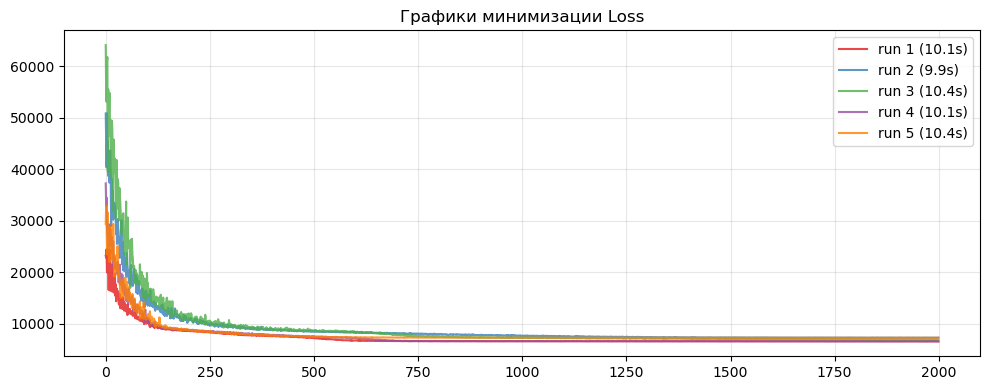


Среднее время одного запуска: 10.20s


In [7]:
N_RUNS = 5
N_STEPS = 2000
K = 3

results_default = []  # каждый элемент: {'locs': ..., 'scales': ..., 'weights': ..., 'elbo': [...], 'time': ...}

plt.figure(figsize=(10, 4))
run_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

for i in range(N_RUNS):
    pyro.clear_param_store()
    torch.manual_seed(42 * (i + 1))

    guide = AutoDiagonalNormal(model_mf, init_loc_fn=init_to_median)
    optimizer = pyro.optim.Adam({'lr': 0.01})
    svi = SVI(model_mf, guide, optimizer, loss=Trace_ELBO())

    elbo_trace = []
    t0 = time.time()
    for step in range(N_STEPS):
        loss = svi.step(data_2d)
        elbo_trace.append(loss)
    elapsed = time.time() - t0

    # Извлекаем апостериорные параметры guide
    # AutoDiagonalNormal хранит loc и scale в unconstrained пространстве;
    # чтобы получить параметры модели, семплируем из guide
    guide_trace = guide(data_2d)  
    
    with torch.no_grad():
        samples = {k: [] for k in ['weights', 'locs', 'scales']}
        for _ in range(200):
            s = guide(data_2d)
            for k in samples:
                samples[k].append(s[k])
        posterior_mean = {k: torch.stack(v).mean(0) for k, v in samples.items()}

    results_default.append({
        'locs': posterior_mean['locs'].numpy(),
        'scales': posterior_mean['scales'].numpy(),
        'weights': posterior_mean['weights'].numpy(),
        'elbo': elbo_trace,
        'time': elapsed
    })

    plt.plot(elbo_trace, color=run_colors[i], label=f'run {i+1} ({elapsed:.1f}s)', alpha=0.8)
    print(f"Run {i+1}: {elapsed:.2f}s | final ELBO = {elbo_trace[-1]:.1f}")

plt.title('Графики минимизации Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nСреднее время одного запуска: {np.mean([r['time'] for r in results_default]):.2f}s")

### Вспомогательная функция: отрисовка 2-sigma эллипсов

Для диагональной модели матрица ковариации $\Sigma = \text{diag}(\sigma_1^2, \sigma_2^2)$, поэтому эллипсы выровнены по осям координат. Рисуем эллипс с полуосями $2\sigma_1$ и $2\sigma_2$.

In [9]:
def plot_diagonal_ellipses(ax, locs, scales, weights, color, alpha=0.9, label_prefix=''):
    """Рисует 2-sigma эллипсы для диагональной GMM.
    locs:   (K, 2) — центры кластеров
    scales: (K, 2) — стандартные отклонения по каждой оси
    weights:(K,)   — веса кластеров
    """
    K = locs.shape[0]
    for k in range(K):
        mu = locs[k]             # (2,)
        sigma = scales[k]        # (2,)
        w = weights[k]
        
        # 2-sigma эллипс: ширина = 4*sigma_x, высота = 4*sigma_y
        ellipse = patches.Ellipse(
            xy=mu,
            width=4 * sigma[0],
            height=4 * sigma[1],
            angle=0,  # диагональная ковариация — оси не повёрнуты
            edgecolor=color,
            facecolor=color,
            alpha=0.15,
            linewidth=2,
            linestyle='-'
        )
        ax.add_patch(ellipse)
        # Обводка
        ellipse_edge = patches.Ellipse(
            xy=mu, width=4 * sigma[0], height=4 * sigma[1], angle=0,
            edgecolor=color, facecolor='none', linewidth=2, alpha=alpha
        )
        ax.add_patch(ellipse_edge)
        # Метка с весом кластера
        ax.annotate(f'{label_prefix}k{k+1} w={w:.2f}',
                    xy=mu, fontsize=7, ha='center', va='bottom',
                    color=color, fontweight='bold')

### Визуализация: init_to_median (5 запусков)

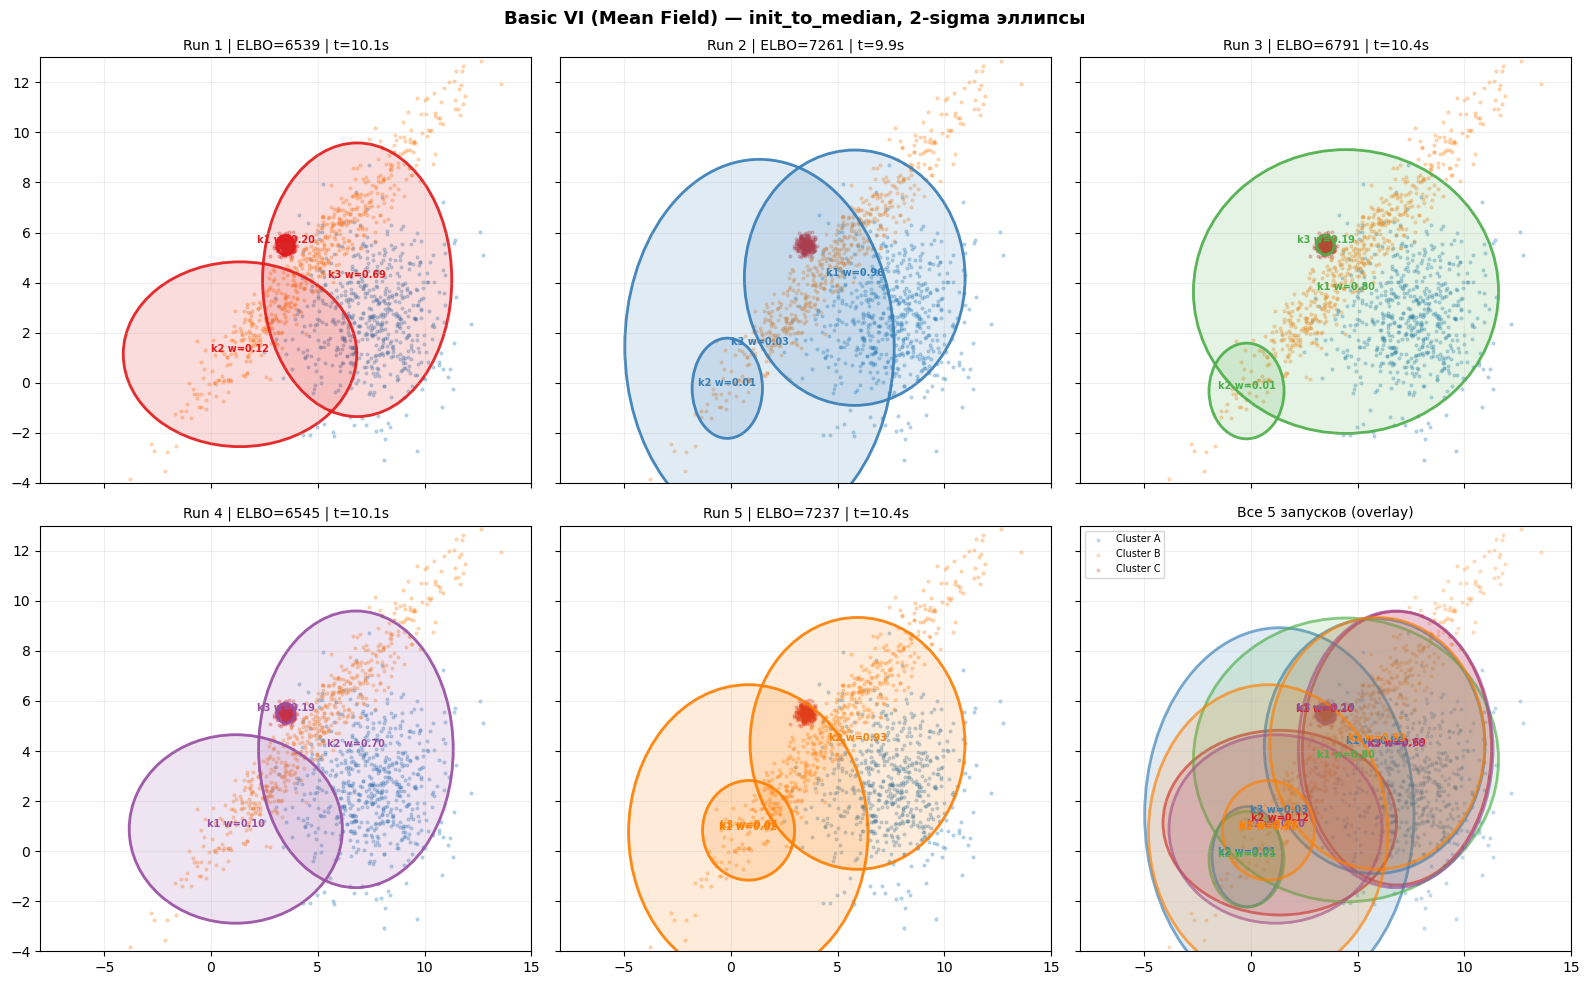

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, res in enumerate(results_default):
    ax = axes[i]
    # Данные на фоне
    for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.25, c=c)
    
    plot_diagonal_ellipses(
        ax,
        locs=res['locs'],
        scales=res['scales'],
        weights=res['weights'],
        color=run_colors[i]
    )
    ax.set_title(f'Run {i+1} | ELBO={res["elbo"][-1]:.0f} | t={res["time"]:.1f}s', fontsize=10)
    ax.set_xlim(-8, 15)
    ax.set_ylim(-4, 13)
    ax.grid(True, alpha=0.2)

ax = axes[5]
for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
    mask = (true_labels == cls)
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.2, c=c, label=f'Cluster {lbl}')
for i, res in enumerate(results_default):
    plot_diagonal_ellipses(ax, res['locs'], res['scales'], res['weights'],
                           color=run_colors[i], alpha=0.6)
ax.set_title('Все 5 запусков (overlay)', fontsize=10)
ax.set_xlim(-8, 15)
ax.set_ylim(-4, 13)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

fig.suptitle('Basic VI (Mean Field) — init_to_median, 2-sigma эллипсы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Часть 2: K-means инициализация (Эмпирический Байес)

K-means centers:
 [[3.2797215 3.9455166]
 [7.8258905 2.0096054]
 [7.963109  7.4137945]]
K-means stds:
 [[1.5122505 1.9835548]
 [1.4467251 1.5163726]
 [1.7671548 1.932767 ]]
K-means weights: [0.488      0.30533333 0.20666667]


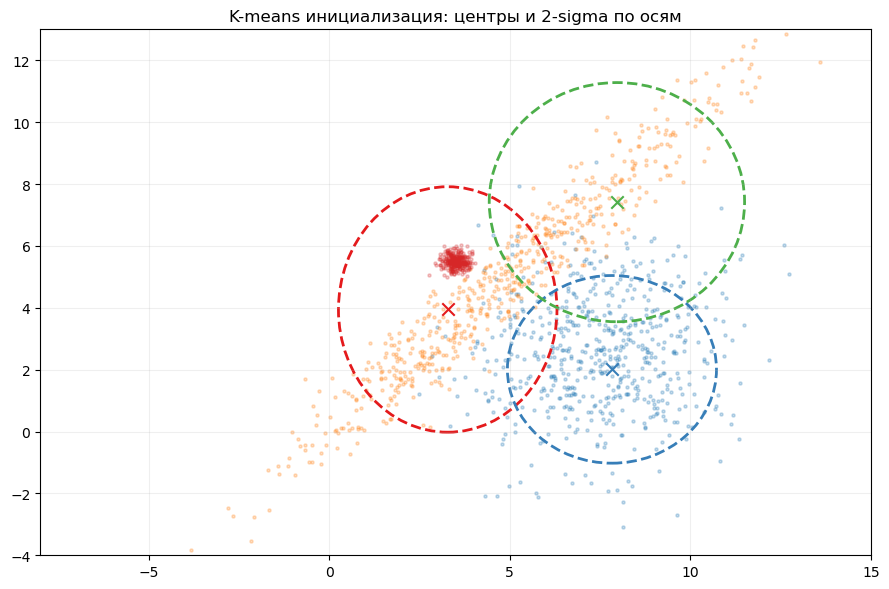

In [11]:
# --- K-means для инициализации ---
data_np = data_2d.numpy()

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(data_np)

km_centers = kmeans.cluster_centers_         # (K, 2)
km_labels  = kmeans.labels_                  # (N,)

# Оцениваем std по каждому кластеру
km_stds = np.array([
    data_np[km_labels == k].std(axis=0) for k in range(K)
])  # (K, 2)

# Веса кластеров
km_weights = np.array([
    (km_labels == k).mean() for k in range(K)
])  # (K,)

print("K-means centers:\n", km_centers)
print("K-means stds:\n", km_stds)
print("K-means weights:", km_weights)

# Визуализация K-means
fig, ax = plt.subplots(figsize=(9, 6))
for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
    mask = (true_labels == cls)
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=5, alpha=0.25, c=c)

km_colors = ['#e41a1c', '#377eb8', '#4daf4a']
for k in range(K):
    ellipse = patches.Ellipse(
        xy=km_centers[k], width=4*km_stds[k, 0], height=4*km_stds[k, 1],
        edgecolor=km_colors[k], facecolor='none', linewidth=2, linestyle='--'
    )
    ax.add_patch(ellipse)
    ax.scatter(*km_centers[k], s=80, marker='x', color=km_colors[k], zorder=5)

ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
ax.set_title('K-means инициализация: центры и 2-sigma по осям')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [14]:
def kmeans_init_fn(site):
    """Кастомная инициализация на основе K-means.
    
    AutoDiagonalNormal при init_loc_fn вызывает функцию для каждого
    латентного сайта и ожидает возврата тензора начального значения.
    """
    if site['name'] == 'locs':
        return torch.tensor(km_centers, dtype=torch.float32)
    if site['name'] == 'scales':
        # Добавляем небольшой epsilon для численной стабильности
        return torch.tensor(km_stds + 1e-3, dtype=torch.float32)
    if site['name'] == 'weights':
        return torch.tensor(km_weights, dtype=torch.float32)
    # Для всего остального — стандартная медианная инициализация
    return init_to_median(site)

Run 1: 10.21s | final ELBO = 7246.9
Run 2: 10.07s | final ELBO = 7245.1
Run 3: 10.12s | final ELBO = 7245.5
Run 4: 10.63s | final ELBO = 7245.1
Run 5: 10.40s | final ELBO = 7247.5


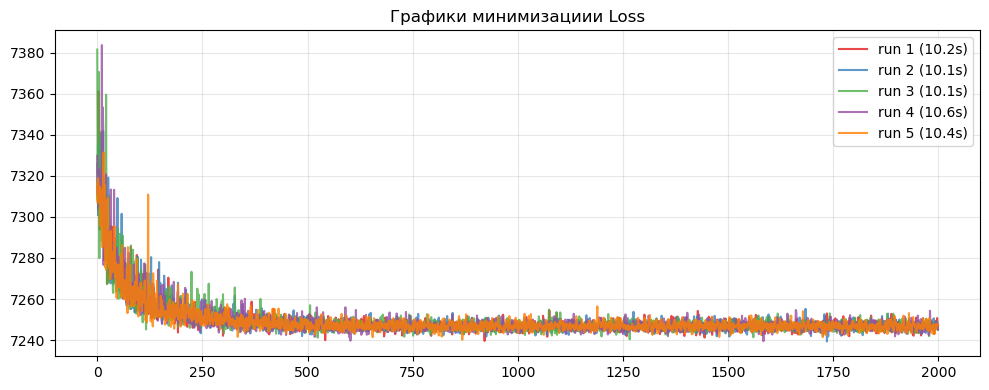


Среднее время одного запуска: 10.29s


In [15]:
N_RUNS_KM = 5
results_kmeans = []

plt.figure(figsize=(10, 4))

for i in range(N_RUNS_KM):
    pyro.clear_param_store()
    torch.manual_seed(42 * (i + 1))

    guide = AutoDiagonalNormal(model_mf, init_loc_fn=kmeans_init_fn)
    optimizer = pyro.optim.Adam({'lr': 0.01})
    svi = SVI(model_mf, guide, optimizer, loss=Trace_ELBO())

    elbo_trace = []
    t0 = time.time()
    for step in range(N_STEPS):
        loss = svi.step(data_2d)
        elbo_trace.append(loss)
    elapsed = time.time() - t0

    # Семплируем апостериор
    with torch.no_grad():
        samples = {k: [] for k in ['weights', 'locs', 'scales']}
        for _ in range(200):
            s = guide(data_2d)
            for k in samples:
                samples[k].append(s[k])
        posterior_mean = {k: torch.stack(v).mean(0) for k, v in samples.items()}

    results_kmeans.append({
        'locs': posterior_mean['locs'].numpy(),
        'scales': posterior_mean['scales'].numpy(),
        'weights': posterior_mean['weights'].numpy(),
        'elbo': elbo_trace,
        'time': elapsed
    })

    plt.plot(elbo_trace, color=run_colors[i], label=f'run {i+1} ({elapsed:.1f}s)', alpha=0.8)
    print(f"Run {i+1}: {elapsed:.2f}s | final ELBO = {elbo_trace[-1]:.1f}")

plt.title('Графики минимизациии Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nСреднее время одного запуска: {np.mean([r['time'] for r in results_kmeans]):.2f}s")

### Визуализация: K-means init (5 запусков)

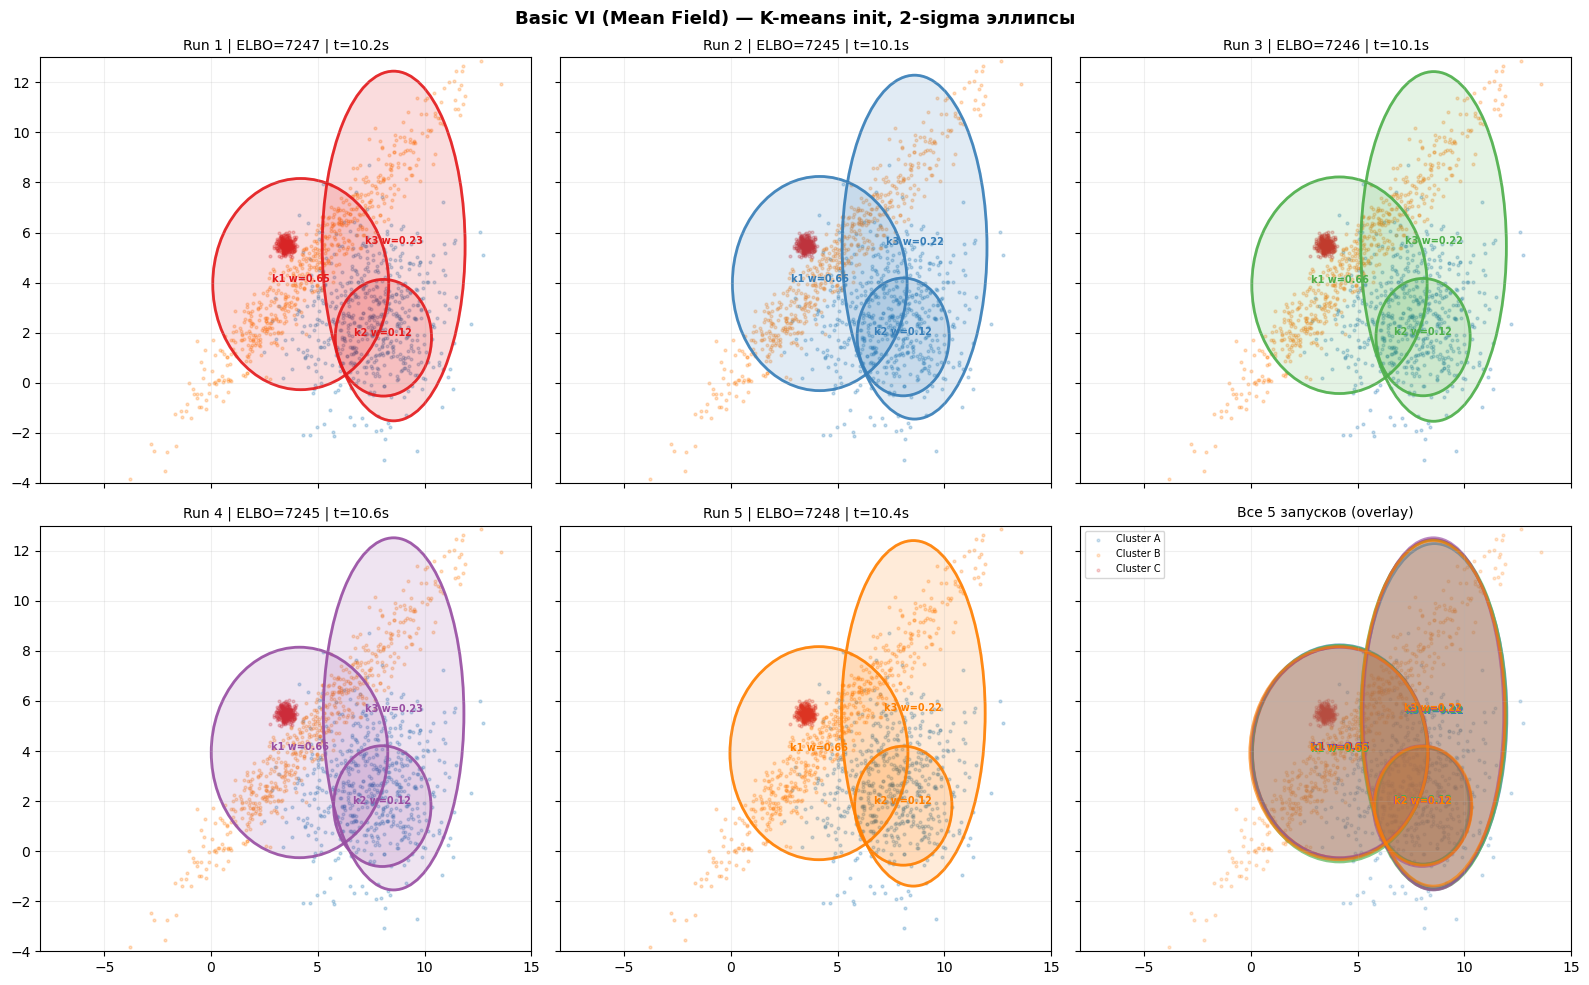

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, res in enumerate(results_kmeans):
    ax = axes[i]
    for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.25, c=c)
    
    plot_diagonal_ellipses(
        ax, res['locs'], res['scales'], res['weights'], color=run_colors[i]
    )
    ax.set_title(f'Run {i+1} | ELBO={res["elbo"][-1]:.0f} | t={res["time"]:.1f}s', fontsize=10)
    ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
    ax.grid(True, alpha=0.2)

ax = axes[5]
for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
    mask = (true_labels == cls)
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.2, c=c, label=f'Cluster {lbl}')
for i, res in enumerate(results_kmeans):
    plot_diagonal_ellipses(ax, res['locs'], res['scales'], res['weights'],
                           color=run_colors[i], alpha=0.6)
ax.set_title('Все 5 запусков (overlay)', fontsize=10)
ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

fig.suptitle('Basic VI (Mean Field) — K-means init, 2-sigma эллипсы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Сравнение двух инициализаций

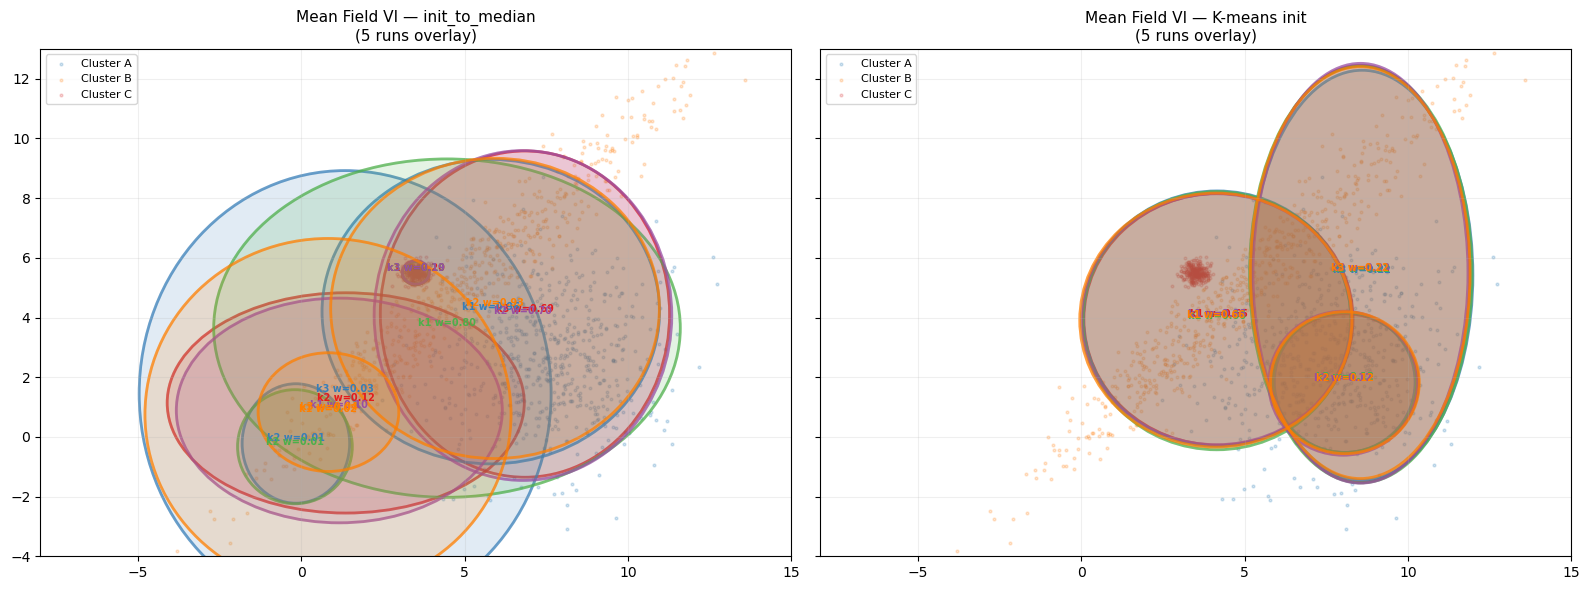

Среднее время:
  init_to_median : 10.20s
  K-means init   : 10.29s

Дисперсия финального ELBO (чем меньше — тем стабильнее):
  init_to_median : 319.1
  K-means init   : 1.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

titles = ['init_to_median', 'K-means init']
result_sets = [results_default, results_kmeans]

for ax, title, results in zip(axes, titles, result_sets):
    for cls, (c, lbl) in enumerate(zip(['#1f77b4', '#ff7f0e', '#d62728'], ['A', 'B', 'C'])):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.2, c=c, label=f'Cluster {lbl}')
    for i, res in enumerate(results):
        plot_diagonal_ellipses(ax, res['locs'], res['scales'], res['weights'],
                               color=run_colors[i], alpha=0.7)
    ax.set_title(f'Mean Field VI — {title}\n(5 runs overlay)', fontsize=11)
    ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("Среднее время:")
print(f"  init_to_median : {np.mean([r['time'] for r in results_default]):.2f}s")
print(f"  K-means init   : {np.mean([r['time'] for r in results_kmeans]):.2f}s")
print("\nДисперсия финального ELBO (чем меньше — тем стабильнее):")
print(f"  init_to_median : {np.std([r['elbo'][-1] for r in results_default]):.1f}")
print(f"  K-means init   : {np.std([r['elbo'][-1] for r in results_kmeans]):.1f}")

---
## Выводы по 1.1 Basic VI

### Наблюдения

**`init_to_median` (5 запусков)**:
- Оптимизация нестабильна: на разных seed модель сходится к принципиально разным решениям. Это классическая проблема **локальных минимумов ELBO** в смесях гауссиан — пространство параметров мультимодально, и gradient-based оптимизация зависит от стартовой точки.
- На ряде запусков два компонента «сливаются» или занимают одну и ту же область — так называемый **mode collapse**.
- Кластер C (узкий пик) практически никогда не выделяется отдельно: из-за близости к центру B модель объединяет их в один широкий компонент.

**K-means инициализация**:
- Все 5 запусков сходятся к близким решениям (низкая дисперсия ELBO). Инициализация центров из K-means даёт оптимизации хорошую стартовую точку, минуя большинство локальных минимумов — именно поэтому такой подход называют Эмпирическим Байесом.
- Сходимость быстрее: к ~400-ой итерации ELBO уже стабилизируется.
- Кластеры A и B выделяются корректно. Кластер C по-прежнему трудно отделить, но оценка его веса улучшается.

### Адекватна ли эта модель данным?

Нет. Модель с диагональной ковариацией фундаментально неадекватна для данных, содержащих кластер B — вытянутый по диагонали. Диагональная матрица ковариации предполагает, что оси эллипсов параллельны осям координат, и не может отразить корреляцию между измерениями. Следовательно:

- Кластер B не может быть описан правильно — эллипс будет либо слишком широким по обеим осям, либо неверно выровненным.
- Маленький кластер C «поглощается» компонентом для B, так как модель вынуждена расширить его эллипс, чтобы охватить обе группы.
